In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [ ]:
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.shape


(4000, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Farm_ID,4000
State,8
District,10
Crop,8
Season,3
Farm_Area_Hectares,1370
Rainfall_mm,3256
Avg_Temperature_C,204
Humidity_pct,573
Sunlight_Hours_Day,71


In [ ]:


df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df["Rainfall_mm"].median()
)

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.shape

(4000, 28)

In [ ]:
season_count = df["Season"].value_counts()

season_count

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


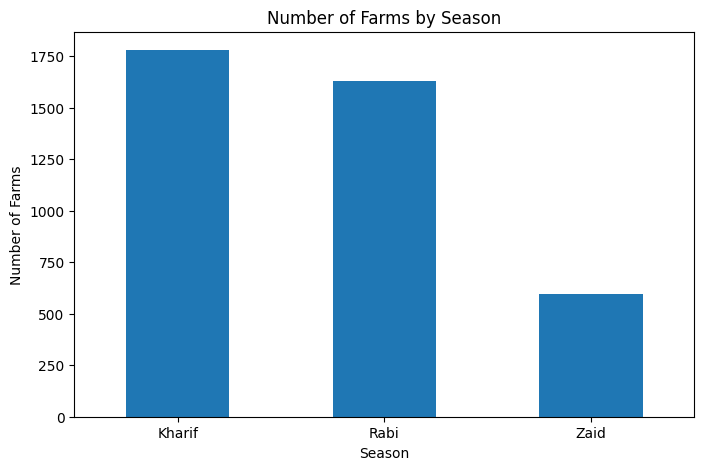

In [ ]:
plt.figure(figsize=(8, 5))

season_count.plot(kind="bar")

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.xticks(rotation=0)
plt.show()

In [ ]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


### Finding:

Kharif had the best average yield at 5.63 tonnes/ha. Rabi was next at 5.04 tonnes/ha, while Zaid had the lowest average yield at 4.64 tonnes/ha.

In [ ]:
plt.figure(figsize=(8, 5))

season_yield.plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=0)
plt.show()


In [ ]:
season_profit = df.groupby("Season")["Profit_INR"].mean()

season_profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


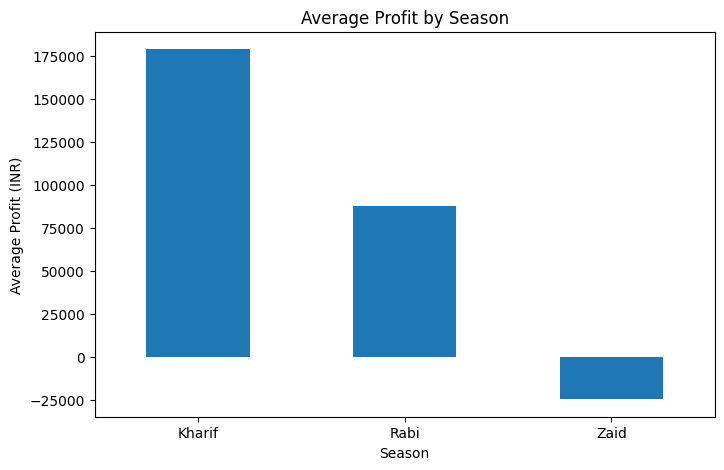

In [ ]:
plt.figure(figsize=(8, 5))

season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=0)
plt.show()

### Finding:

Kharif gave the highest average profit of ₹178,914.65. Rabi made an average profit of ₹87,689.47. Zaid had a negative average profit of ₹24,804.82, which means the average cost was more than the average revenue.

In [ ]:
season_production = df.groupby("Season")["Production_Tonnes"].mean()

season_production

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


### Finding:

The average production was highest in Kharif at 46.31 tonnes. Rabi followed with 41.49 tonnes, and Zaid had the lowest average production at 38.89 tonnes.

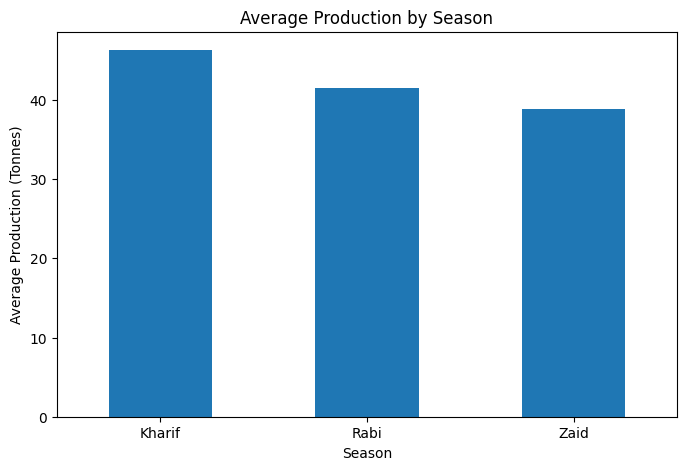

In [ ]:
plt.figure(figsize=(8, 5))

season_production.plot(kind="bar")

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")

plt.xticks(rotation=0)
plt.show()

In [ ]:
season_water = df.groupby("Season")["Water_Used_m3"].mean()

season_water

,Water_Used_m3
Season,
Kharif,6102.201237
Rabi,5846.987093
Zaid,6419.893939


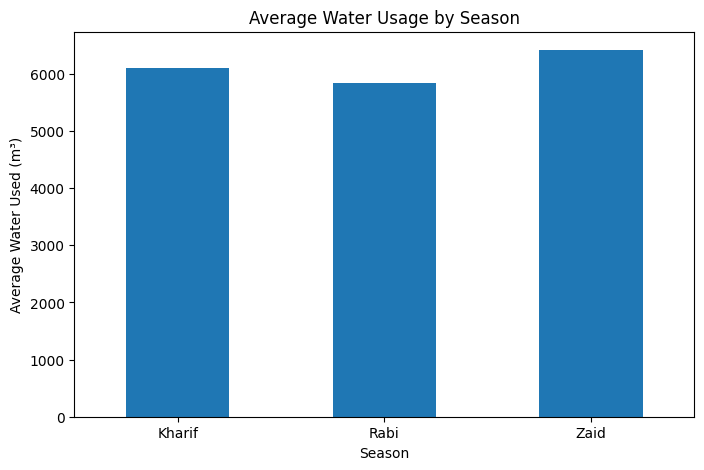

In [ ]:
plt.figure(figsize=(8, 5))

season_water.plot(kind="bar")

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")

plt.xticks(rotation=0)
plt.show()

### Finding:

Zaid used the most water on average, about 6,419.89 m³. Kharif used 6,102.20 m³, while Rabi used the least at 5,846.99 m³.

In [ ]:
season_efficiency = df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean()

season_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


### Finding:

Kharif had the best water efficiency at 5.89 tonnes per 1,000 m³. Rabi was at 5.19, and Zaid had the lowest efficiency at 4.41 tonnes per 1,000 m³.

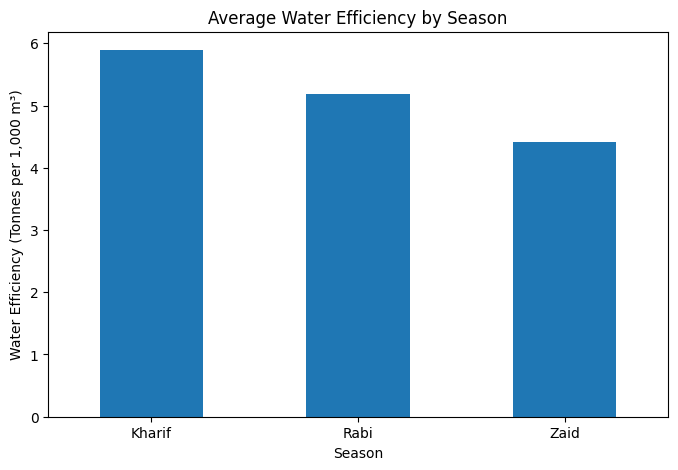

In [ ]:
plt.figure(figsize=(8, 5))

season_efficiency.plot(kind="bar")

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes per 1,000 m³)")

plt.xticks(rotation=0)
plt.show()

In [ ]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean()

crop_yield.sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


### Finding:

Sugarcane had by far the highest average yield at 46.64 tonnes/ha. Maize and Rice followed at 2.71 and 2.43 tonnes/ha. Pulses had the lowest average yield at 0.92 tonnes/ha.

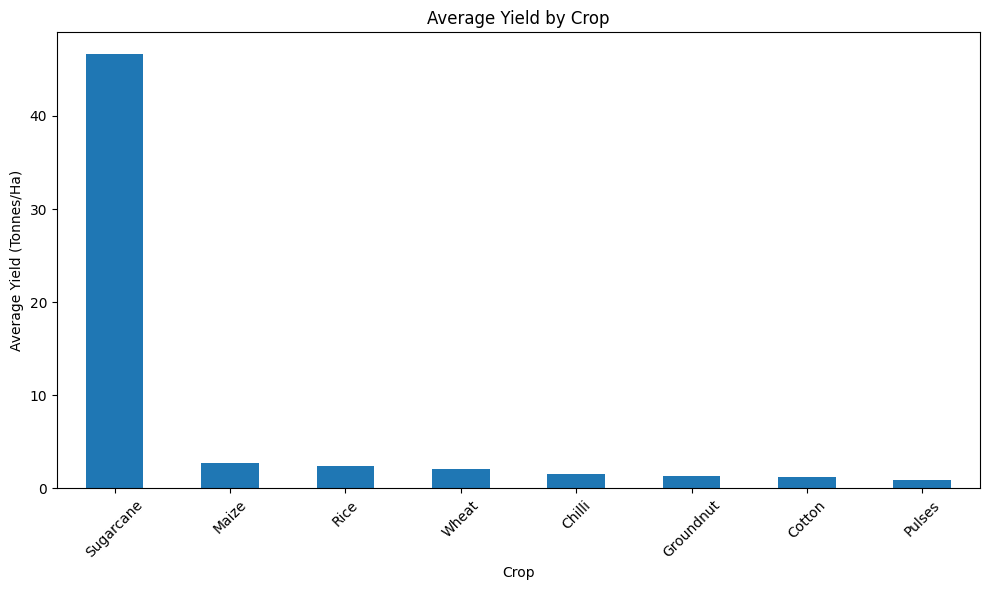

In [ ]:
plt.figure(figsize=(10, 6))

crop_yield.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
crop_profit = df.groupby("Crop")["Profit_INR"].mean()

crop_profit.sort_values(ascending=False)

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


### Finding:

Sugarcane made the highest average profit of ₹817,187.99, followed by Chilli at ₹750,878.34. Cotton and Groundnut also had positive profits. Pulses, Maize, Rice and Wheat had negative average profits, with Wheat being the lowest at −₹123,398.34.

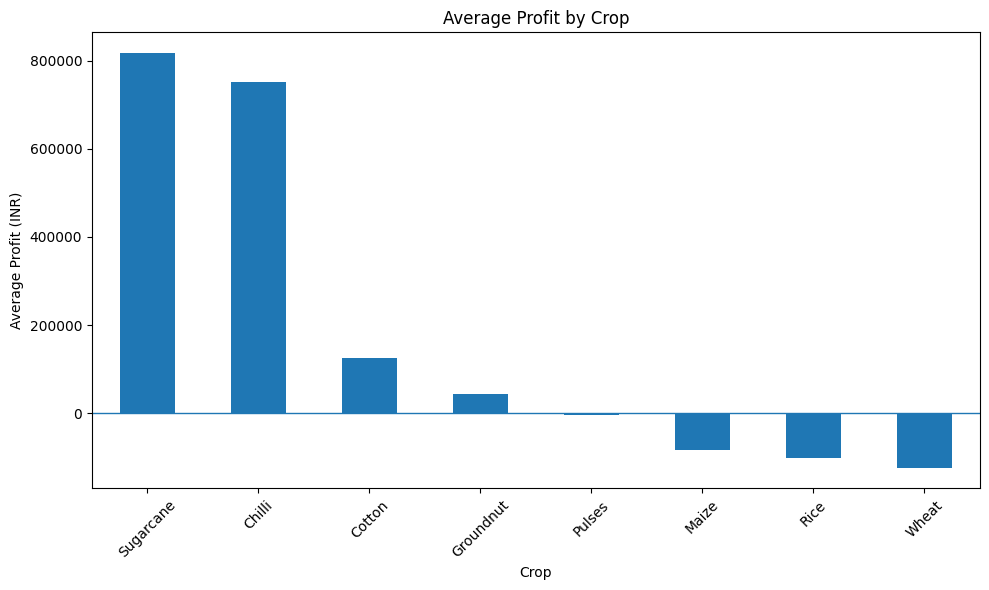

In [ ]:
plt.figure(figsize=(10, 6))

crop_profit.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=45)
plt.axhline(y=0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
irrigation_count = df["Irrigation_Method"].value_counts()

irrigation_count

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


### Finding:

Flood irrigation was used most often, with 1,310 records. Rainfed had 1,041 records, followed by Drip with 915. Sprinkler was used the least, with 734 records.

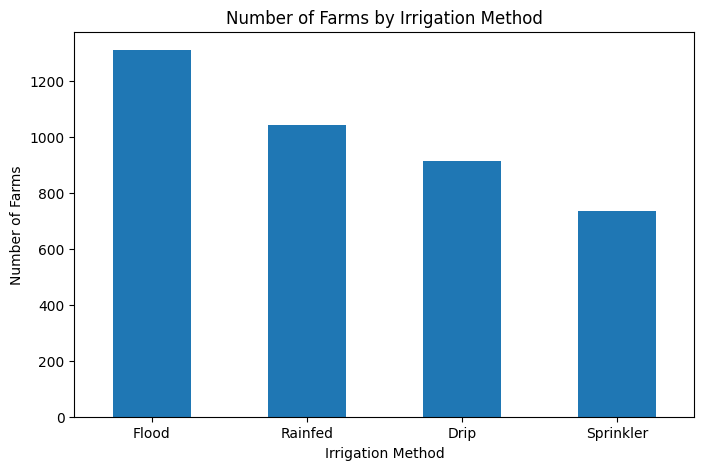

In [ ]:
plt.figure(figsize=(8, 5))

irrigation_count.plot(kind="bar")

plt.title("Number of Farms by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")

plt.xticks(rotation=0)
plt.show()

In [ ]:
irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean()

irrigation_yield.sort_values(ascending=False)

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


### Finding:

Drip irrigation had the highest average yield at 6.58 tonnes/ha. Sprinkler came next at 5.16 tonnes/ha, followed by Flood at 4.86. Rainfed had the lowest average yield at 4.60 tonnes/ha.

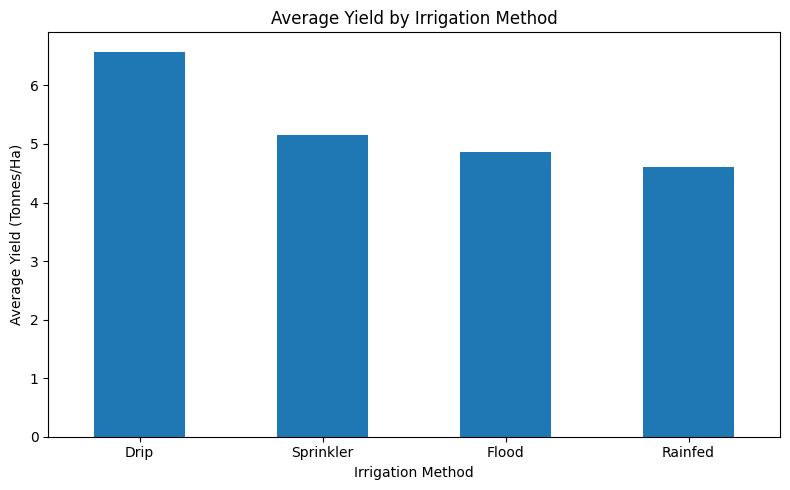

In [ ]:
plt.figure(figsize=(8, 5))

irrigation_yield.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
irrigation_profit = df.groupby("Irrigation_Method")["Profit_INR"].mean()

irrigation_profit.sort_values(ascending=False)

,Profit_INR
Irrigation_Method,
Drip,219625.997814
Sprinkler,91121.079019
Rainfed,79050.365034
Flood,73354.022901


### Finding:

Drip irrigation gave the highest average profit of ₹219,626.00. Sprinkler averaged ₹91,121.08, Rainfed ₹79,050.37, and Flood had the lowest average profit at ₹73,354.02.

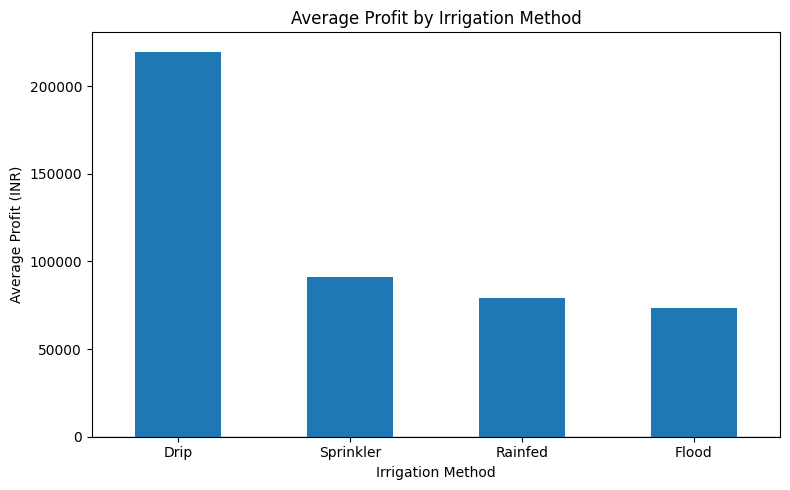

In [ ]:
plt.figure(figsize=(8, 5))

irrigation_profit.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Profit by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=0)
plt.axhline(y=0, linewidth=1)
plt.tight_layout()
plt.show()

### Finding:

Among the irrigation methods, Drip had the highest average profit. Its average was ₹219,626, compared with ₹91,121 for Sprinkler, ₹79,050 for Rainfed and ₹73,354 for Flood.

In [ ]:
state_count = df["State"].value_counts()

state_count

,count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484


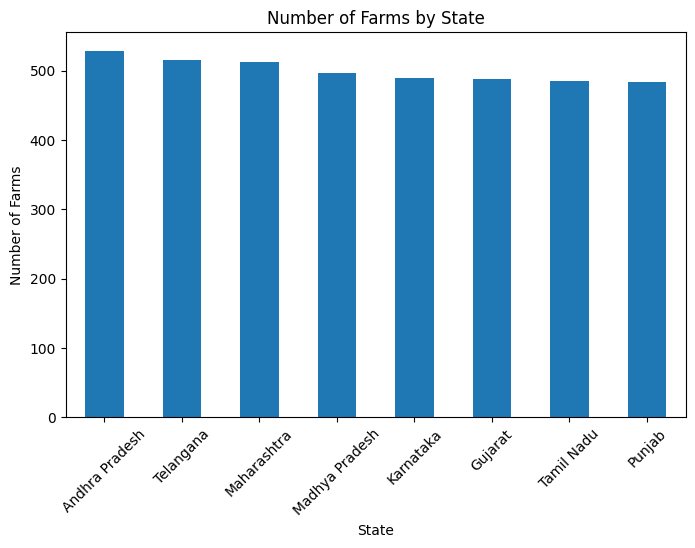

In [ ]:
plt.figure(figsize=(8, 5))

state_count.plot(kind="bar")

plt.title("Number of Farms by State")
plt.xlabel("State")
plt.ylabel("Number of Farms")

plt.xticks(rotation=45)
plt.show()

### Finding:

Andhra Pradesh had the most farm records with 529, followed by Telangana with 516 and Maharashtra with 512. Punjab had the fewest records at 484. The difference between the states is not very large.

In [ ]:
state_yield = df.groupby("State")["Yield_Tonnes_Ha"].mean()

state_yield

,Yield_Tonnes_Ha
State,
Andhra Pradesh,4.628771
Gujarat,5.659016
Karnataka,5.685481
Madhya Pradesh,4.989940
Maharashtra,5.017480
Punjab,6.121116
Tamil Nadu,4.875175
Telangana,5.044477


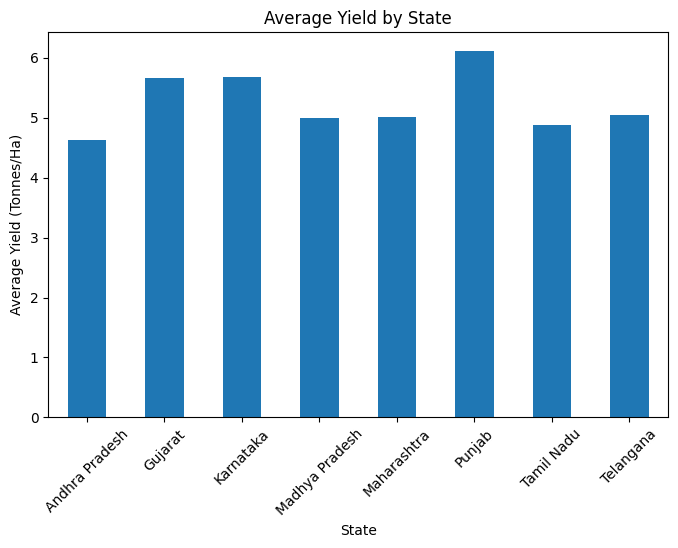

In [ ]:
plt.figure(figsize=(8, 5))

state_yield.plot(kind="bar")

plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)
plt.show()

### Finding:

Punjab had the highest average yield at 6.12 tonnes/ha. Karnataka and Gujarat followed with 5.69 and 5.66 tonnes/ha. Andhra Pradesh had the lowest average yield at 4.63 tonnes/ha.

In [ ]:
state_profit = df.groupby("State")["Profit_INR"].mean()

state_profit

,Profit_INR
State,
Andhra Pradesh,73453.527410
Gujarat,117568.235656
Karnataka,119422.335378
Madhya Pradesh,86840.756539
Maharashtra,135428.855469
Punjab,136025.636364
Tamil Nadu,117744.748454
Telangana,108829.616279


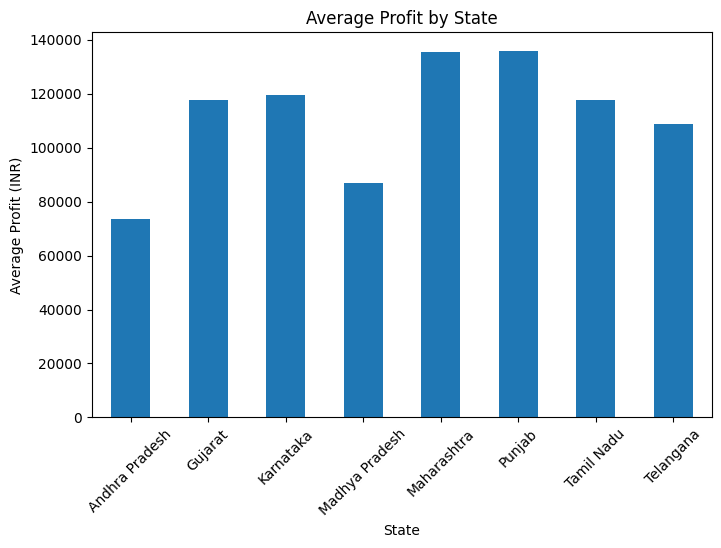

In [ ]:
plt.figure(figsize=(8, 5))

state_profit.plot(kind="bar")

plt.title("Average Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=45)
plt.show()

### Finding:

Punjab had the highest average profit at ₹136,026, closely followed by Maharashtra at ₹135,429. Andhra Pradesh had the lowest average profit at ₹73,454.

In [ ]:
state_production = df.groupby("State")["Production_Tonnes"].mean()

state_production

,Production_Tonnes
State,
Andhra Pradesh,36.913157
Gujarat,48.331988
Karnataka,47.732720
Madhya Pradesh,37.559517
Maharashtra,43.984043
Punjab,52.233099
Tamil Nadu,40.840371
Telangana,39.254186


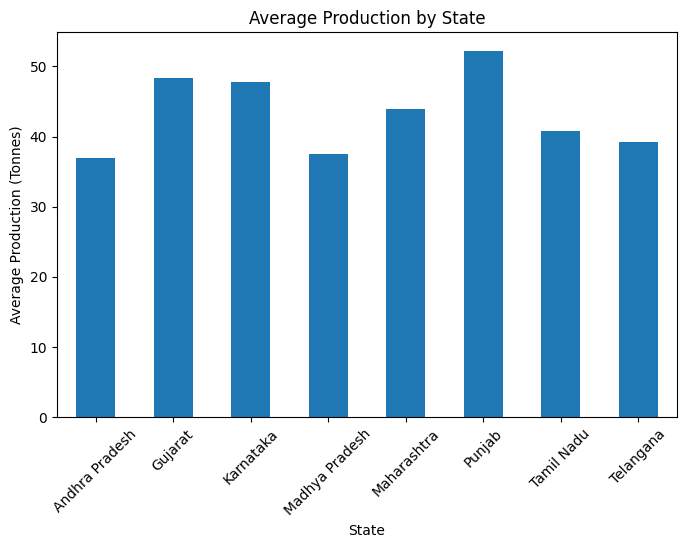

In [ ]:
plt.figure(figsize=(8, 5))

state_production.plot(kind="bar")

plt.title("Average Production by State")
plt.xlabel("State")
plt.ylabel("Average Production (Tonnes)")

plt.xticks(rotation=45)
plt.show()

### Finding:

Punjab had the highest average production at 52.23 tonnes. Gujarat and Karnataka followed at 48.33 and 47.73 tonnes. Andhra Pradesh had the lowest average production at 36.91 tonnes.

In [ ]:
state_water = df.groupby("State")["Water_Used_m3"].mean()

state_water

,Water_Used_m3
State,
Andhra Pradesh,6058.379962
Gujarat,6142.500000
Karnataka,6414.327198
Madhya Pradesh,5663.919517
Maharashtra,5968.082031
Punjab,6565.915289
Tamil Nadu,5775.218557
Telangana,5801.825581


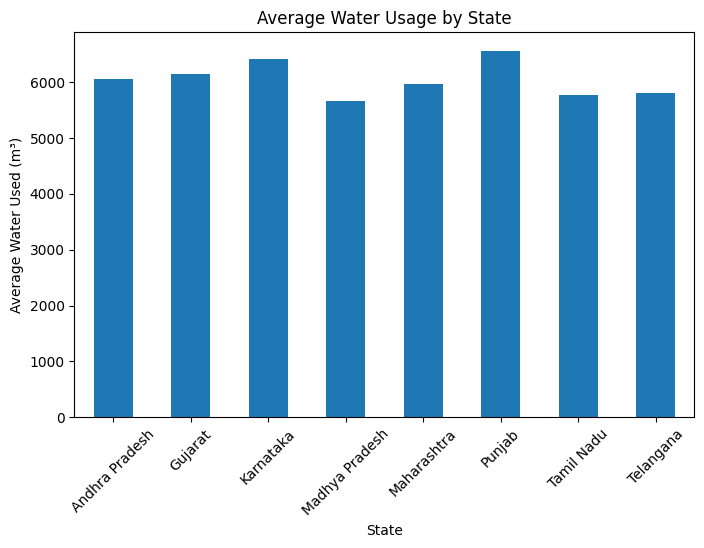

In [ ]:
plt.figure(figsize=(8, 5))

state_water.plot(kind="bar")

plt.title("Average Water Usage by State")
plt.xlabel("State")
plt.ylabel("Average Water Used (m³)")

plt.xticks(rotation=45)
plt.show()

### Finding:

Punjab used the most water on average, at 6,565.92 m³. Karnataka used 6,414.33 m³ and Gujarat 6,142.50 m³. Madhya Pradesh had the lowest average water usage at 5,663.92 m³.

In [ ]:
state_efficiency = df.groupby("State")["Water_Efficiency_t_per_1000m3"].mean()

state_efficiency

,Water_Efficiency_t_per_1000m3
State,
Andhra Pradesh,5.031427
Gujarat,5.578648
Karnataka,5.562389
Madhya Pradesh,5.266622
Maharashtra,5.284379
Punjab,5.621700
Tamil Nadu,5.305066
Telangana,5.464866


### Finding:

Punjab had the highest average water efficiency at 5.62 tonnes per 1,000 m³. Gujarat and Karnataka followed at 5.58 and 5.56. Andhra Pradesh had the lowest value at 5.03 tonnes per 1,000 m³.

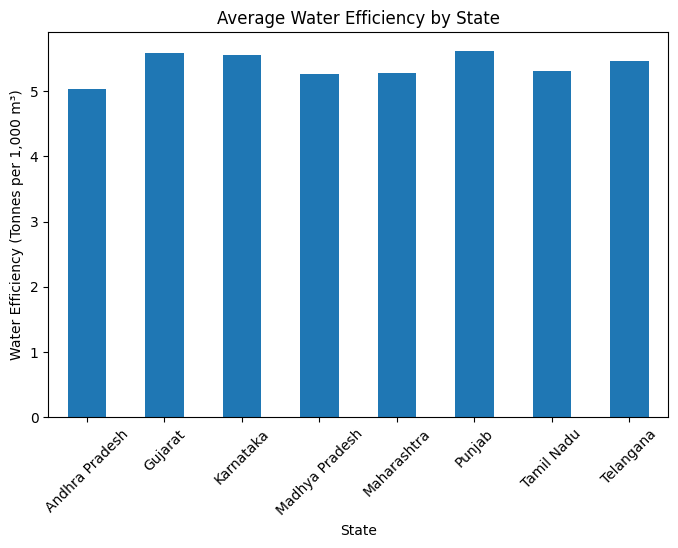

In [ ]:
plt.figure(figsize=(8, 5))

state_efficiency.plot(kind="bar")

plt.title("Average Water Efficiency by State")
plt.xlabel("State")
plt.ylabel("Water Efficiency (Tonnes per 1,000 m³)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
crop_efficiency = df.groupby("Crop")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False)

crop_efficiency

,Water_Efficiency_t_per_1000m3
Crop,
Sugarcane,30.477672
Maize,5.602995
Wheat,4.628393
Groundnut,3.154795
Chilli,2.947709
Pulses,2.896504
Rice,1.946112
Cotton,1.938016


### Finding:

Sugarcane had the highest average water efficiency at 30.48 tonnes per 1,000 m³. Maize and Wheat followed at 5.60 and 4.63. Cotton had the lowest efficiency at 1.94 tonnes per 1,000 m³.

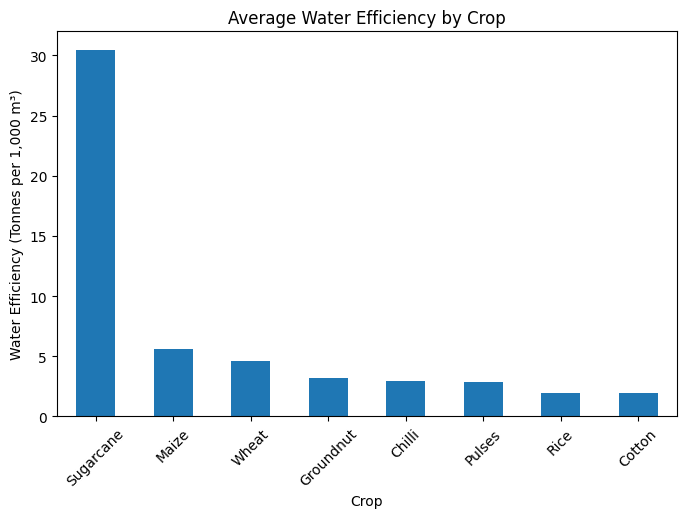

In [ ]:
plt.figure(figsize=(8, 5))

crop_efficiency.plot(kind="bar")

plt.title("Average Water Efficiency by Crop")
plt.xlabel("Crop")
plt.ylabel("Water Efficiency (Tonnes per 1,000 m³)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
season_irrigation_yield = df.groupby(
    ["Season", "Irrigation_Method"]
)["Yield_Tonnes_Ha"].mean().unstack()

season_irrigation_yield

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,7.256296,4.977915,5.703996,4.662243
Rabi,6.111676,5.060589,3.929110,5.307235
Zaid,5.848143,3.984381,3.063786,6.135833


### Finding:

Drip gave the highest average yield in Kharif (7.26 tonnes/ha) and Rabi (6.11 tonnes/ha). In Zaid, Sprinkler had the highest average yield at 6.14 tonnes/ha. Rainfed was generally lower than the other methods.

<Figure size 800x500 with 0 Axes>

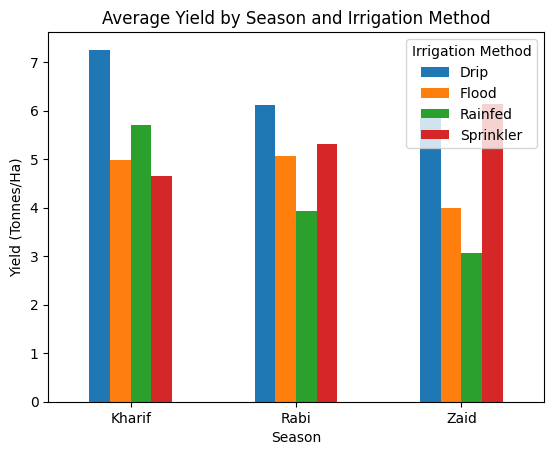

In [ ]:
plt.figure(figsize=(8, 5))

season_irrigation_yield.plot(kind="bar")

plt.title("Average Yield by Season and Irrigation Method")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.xticks(rotation=0)
plt.legend(title="Irrigation Method")
plt.show()

In [ ]:
season_irrigation_profit = df.groupby(
    ["Season", "Irrigation_Method"]
)["Profit_INR"].mean().unstack()

season_irrigation_profit

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,317222.071605,133373.832203,158974.125270,116880.492212
Rabi,187843.221622,58824.798479,45232.479452,76502.068259
Zaid,21291.835714,-69786.778351,-79467.257143,57909.400000


### Finding:

Drip gave the highest average profit in Kharif at ₹317,222 and in Rabi at ₹187,843. In Zaid, Sprinkler was the best at ₹57,909. Flood and Rainfed had negative average profits in Zaid.

<Figure size 800x500 with 0 Axes>

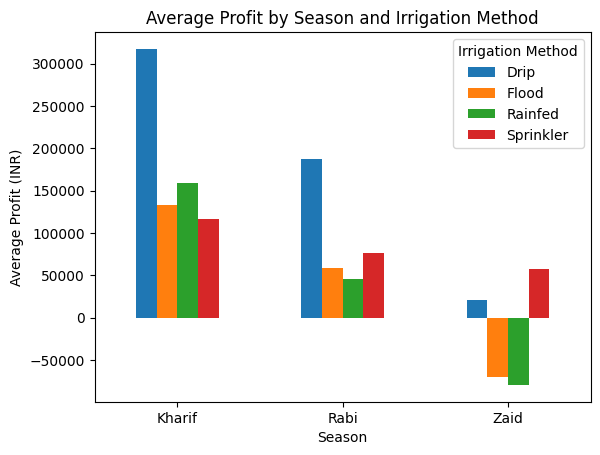

In [ ]:
plt.figure(figsize=(8, 5))

season_irrigation_profit.plot(kind="bar")

plt.title("Average Profit by Season and Irrigation Method")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=0)
plt.legend(title="Irrigation Method")
plt.show()

### Finding:

Drip performed best for profit in Kharif and Rabi. In Zaid, Sprinkler was the only irrigation method with a positive average profit, while Flood and Rainfed showed losses.

In [ ]:
season_crop_yield = df.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean().unstack()

season_crop_yield

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731459,1.374512,1.484974,2.966410,1.036063,2.698376,53.459120,2.253664
Rabi,1.465031,1.198358,1.233164,2.603648,0.875962,2.322847,43.286124,2.057468
Zaid,1.195312,0.960217,1.037778,2.290952,0.669677,1.900490,38.423922,1.748588


### Finding:

Sugarcane had the highest average yield in each season: 53.46 tonnes/ha in Kharif, 43.29 in Rabi and 38.42 in Zaid. Pulses had the lowest average yield across the seasons.

<Figure size 1000x500 with 0 Axes>

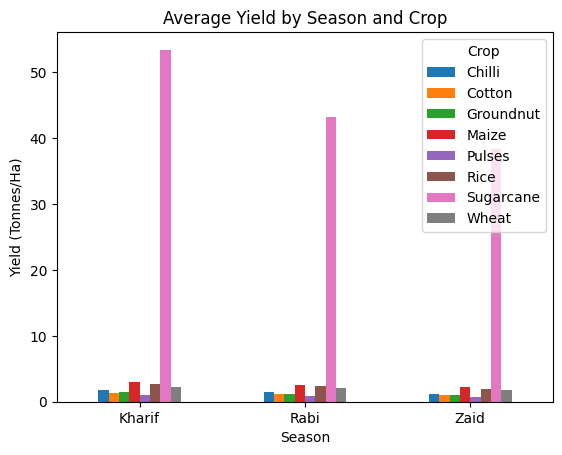

In [ ]:
plt.figure(figsize=(10, 5))

season_crop_yield.plot(kind="bar")

plt.title("Average Yield by Season and Crop")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.xticks(rotation=0)
plt.legend(title="Crop")
plt.show()

In [ ]:
season_crop_profit = df.groupby(
    ["Season", "Crop"]
)["Profit_INR"].mean().unstack()

season_crop_profit

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,954380.421622,216999.548837,108265.440415,-39332.670940,43338.895928,-64903.404459,1.000791e+06,-105871.869863
Rabi,638572.496933,107343.587065,10416.542373,-89133.403433,-14309.136150,-98427.868613,7.316129e+05,-119954.565401
Zaid,448659.093750,-53925.336957,-68872.500000,-194049.166667,-139227.806452,-227239.343137,5.836358e+05,-193208.952941


### Finding:

Sugarcane had the highest average profit in all three seasons, at about ₹10.01 lakh in Kharif, ₹7.32 lakh in Rabi and ₹5.84 lakh in Zaid. Chilli also performed well. Some other crops had negative profits, especially in Zaid.

<Figure size 1000x500 with 0 Axes>

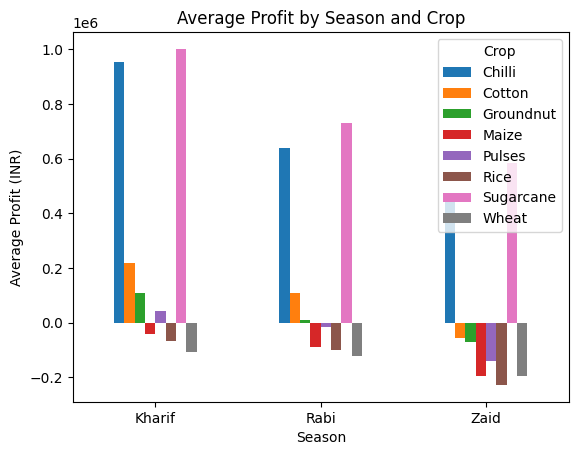

In [ ]:
plt.figure(figsize=(10, 5))

season_crop_profit.plot(kind="bar")

plt.title("Average Profit by Season and Crop")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=0)
plt.legend(title="Crop")
plt.show()

### Finding:

Sugarcane and Chilli were the most profitable crops across the seasons. Profit was generally better in Kharif and lower in Rabi and Zaid. Several crops showed negative profits in Zaid.

In [ ]:
environment_yield = df[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_pH",
        "Soil_Moisture_pct",
        "Yield_Tonnes_Ha"
    ]
].corr()["Yield_Tonnes_Ha"].sort_values(ascending=False)

environment_yield

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Rainfall_mm,0.030951
Humidity_pct,0.012297
Soil_Moisture_pct,0.010999
Avg_Temperature_C,0.009996
Sunlight_Hours_Day,-0.015341
Soil_pH,-0.020672


### Finding:

The correlation values are very close to zero, so the environmental factors in this dataset do not have a strong linear connection with crop yield. Rainfall had the highest positive correlation at 0.031, while Soil pH had the lowest at −0.021.

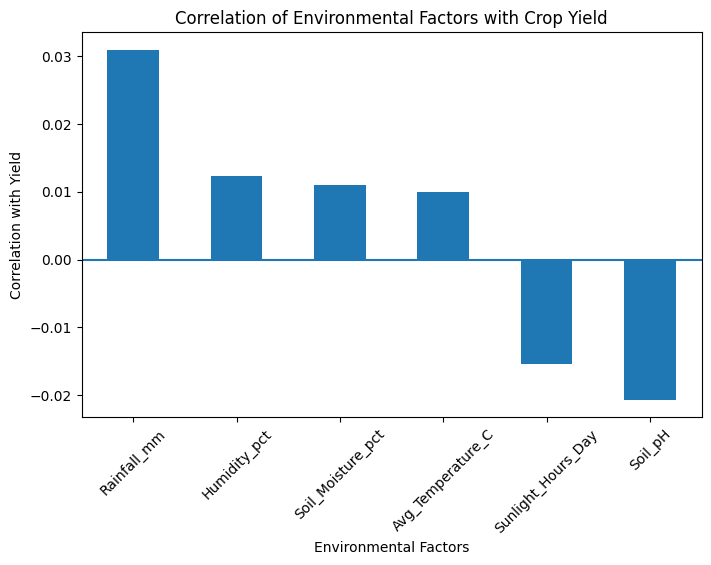

In [ ]:
plt.figure(figsize=(8, 5))

environment_yield.drop("Yield_Tonnes_Ha").plot(kind="bar")

plt.title("Correlation of Environmental Factors with Crop Yield")
plt.xlabel("Environmental Factors")
plt.ylabel("Correlation with Yield")

plt.xticks(rotation=45)
plt.axhline(0)
plt.show()

# Final Conclusion

### Key Insights:

- Kharif performed best overall in terms of average yield, production and profit.
- Zaid had the lowest average yield and also showed a negative average profit.
- Drip irrigation gave the best average yield and profit in Kharif and Rabi.
- Sprinkler performed best in Zaid.
- Sugarcane had the highest average yield and profit among the crops.
- Chilli was also one of the better-performing crops in terms of profit.
- Zaid used the most water, while Kharif had the best water efficiency.
- Punjab had the highest average yield, production, profit and water usage among the states studied.
- The environmental factors tested had very weak linear relationships with crop yield.
- Overall, the results show that season, crop and irrigation method can make a noticeable difference in agricultural performance.